<a href="https://colab.research.google.com/github/sara-iqbal/Multimodal-Dataset-Quality-Audit-Tool/blob/main/multimodal_dataset_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodal Dataset Quality Audit Tool
### Text + Image · Quality Scoring · Diversity Metrics · Dataset Card

**Author:** Sara Iqbal | MSc Data Science

---

## What This Project Does

This project builds a complete **multimodal dataset quality audit pipeline** — processing both text captions and image metadata from a public multimodal dataset, running quality checks across both modalities, measuring diversity, flagging low-quality samples, and producing a structured audit report with a dataset card.

### Pipeline
```
Multimodal Data Ingestion (text captions + image metadata)
        ↓
Text Quality Audit (length · entropy · repetition · language)
        ↓
Image Quality Audit (resolution · aspect ratio · format · size)
        ↓
Caption-Image Alignment Scoring (text relevance to image category)
        ↓
Deduplication (caption-level + image hash)
        ↓
Diversity Analysis (category distribution · caption vocabulary · image dimensions)
        ↓
Quality Tier Assignment (High / Medium / Low / Flagged)
        ↓
Audit Report + Dataset Card
```

In [1]:
# Step 1 — Imports & Setup
!pip install datasets pandas numpy matplotlib Pillow -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json, re, hashlib, warnings
from collections import Counter
from datetime import datetime
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
    'axes.spines.top':False,'axes.spines.right':False,
    'font.family':'DejaVu Sans','axes.grid':True,
    'grid.alpha':0.4,'grid.color':'#cccccc'
})
print("Libraries loaded")
print(f"Run timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Libraries loaded
Run timestamp: 2026-03-25 22:10


In [7]:
# Download images and annotations directly to Colab
!wget -c http://images.cocodataset.org/zips/val2017.zip
!wget -c http://images.cocodataset.org/annotations/annotations_trainval2017.zip

# Unzip the files (-q for quiet mode to avoid long output)
!unzip -q val2017.zip
!unzip -q annotations_trainval2017.zip

# Clean up the zip files to save space
!rm val2017.zip annotations_trainval2017.zip

--2026-03-25 22:20:42--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.217.111, 3.5.25.154, 54.231.229.177, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.217.111|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.80M  43.1MB/s    in 18s     

2026-03-25 22:21:01 (42.2 MB/s) - ‘val2017.zip’ saved [815585330/815585330]

--2026-03-25 22:21:01--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.224.137, 3.5.29.47, 16.15.217.13, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.224.137|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_trainva 10

In [8]:
import json
import os
from PIL import Image
import pandas as pd

# Paths to the files we just downloaded
anno_path = 'annotations/captions_val2017.json'
img_dir = 'val2017/'

print("Loading local MS-COCO annotations...")
with open(anno_path, 'r') as f:
    coco_data = json.load(f)

# Create a quick lookup for image metadata by ID
images_info = {img['id']: img for img in coco_data['images']}

N = 3000
records = []

print(f"Processing {N} image-caption pairs...")
for i, ann in enumerate(coco_data['annotations']):
    if i >= N: break

    img_info = images_info.get(ann['image_id'])
    img_path = os.path.join(img_dir, img_info['file_name'])

    try:
        # We open the image briefly to get dimensions and mode for your audit
        with Image.open(img_path) as img:
            records.append({
                'id':         f"img_{img_info['id']}",
                'caption':    ann['caption'],
                'img_width':  img.width,
                'img_height': img.height,
                'img_mode':   img.mode,
                'img_format': img.format or 'JPEG',
            })
    except Exception as e:
        continue

df = pd.DataFrame(records)

# Calculate additional metrics for your audit
df['aspect_ratio'] = (df['img_width'] / df['img_height'].replace(0,1)).round(3)
df['n_pixels']     = df['img_width'] * df['img_height']
df['caption_len']  = df['caption'].str.len()
df['caption_words']= df['caption'].str.split().str.len()

print(f"Successfully loaded {len(df)} records.")
df.head()

Loading local MS-COCO annotations...
Processing 3000 image-caption pairs...
Successfully loaded 3000 records.


,id,caption,img_width,img_height,img_mode,img_format,aspect_ratio,n_pixels,caption_len,caption_words
0,img_179765,A black Honda motorcycle parked in front of a ...,640,480,RGB,JPEG,1.333,307200,53,10
1,img_179765,A Honda motorcycle parked in a grass driveway,640,480,RGB,JPEG,1.333,307200,45,8
2,img_190236,An office cubicle with four different types of...,640,393,RGB,JPEG,1.628,251520,57,9
3,img_331352,A small closed toilet in a cramped space.,351,500,RGB,JPEG,0.702,175500,41,8
4,img_517069,Two women waiting at a bench next to a street.,640,480,RGB,JPEG,1.333,307200,46,10


In [11]:
# Step 3 — Text Quality Audit (Captions)
import numpy as np
import re
from collections import Counter

def char_entropy(text):
    if not isinstance(text, str) or len(text) < 5:
        return 0
    sample = text[:300]
    counts = Counter(sample)
    total = len(sample)
    return -sum((c/total) * np.log2(c/total) for c in counts.values())

def repetition_ratio(text):
    if not isinstance(text, str) or len(text.split()) == 0:
        return 0
    words = text.lower().split()
    return len(set(words)) / len(words)

def has_special_issues(text):
    if not isinstance(text, str):
        return ['invalid_type']
    flags = []
    if len(text.strip()) < 10:         flags.append('too_short')
    if re.search(r'http\S+', text):    flags.append('has_url')
    if re.search(r'[^\x00-\x7f]', text): flags.append('non_ascii')
    if text == text.upper() and len(text) > 10: flags.append('all_caps')
    return flags

# 1. Run the audit functions
df['caption_entropy']    = df['caption'].apply(char_entropy)
df['caption_repetition'] = df['caption'].apply(repetition_ratio)
df['text_flags']         = df['caption'].apply(has_special_issues)
df['n_text_flags']       = df['text_flags'].apply(len)

# 2. Safely get the max entropy for scaling
max_entropy = df['caption_entropy'].max()
if max_entropy == 0 or np.isnan(max_entropy):
    max_entropy = 1  # Fallback to avoid division by zero

# 3. Calculate text quality score (0-100)
df['text_quality'] = (
    (df['caption_entropy'] / max_entropy * 40).clip(0,40) +
    (df['caption_repetition'] * 30) +
    (df['caption_words'].clip(3,30) / 30 * 20) +
    ((1 - df['n_text_flags'].clip(0,3)/3) * 10)
).round(2)

print("TEXT QUALITY AUDIT COMPLETED")
print("-" * 30)
print(f"Avg text quality score: {df['text_quality'].mean():.2f}")
print(f"Samples with flags:     {(df['n_text_flags']>0).sum()}")

TEXT QUALITY AUDIT COMPLETED
------------------------------
Avg text quality score: 79.43
Samples with flags:     24


In [12]:
# Step 4 — Image Quality Audit (Metadata)

def image_quality_score(row):
    score = 0
    # Resolution score (prefer 224x224 minimum)
    min_dim = min(row['img_width'], row['img_height'])
    if min_dim >= 224:   score += 35
    elif min_dim >= 128: score += 20
    elif min_dim >= 64:  score += 10
    else:                score += 0
    # Aspect ratio score (prefer close to square or standard ratios)
    ar = row['aspect_ratio']
    if 0.5 <= ar <= 2.0:   score += 30
    elif 0.25 <= ar <= 4.0: score += 15
    else:                   score += 0
    # Format score
    if row['img_format'] in ['JPEG','PNG']: score += 20
    else:                                   score += 10
    # Mode score
    if row['img_mode'] == 'RGB': score += 15
    elif row['img_mode'] in ['L','RGBA']: score += 8
    return score

df['img_quality'] = df.apply(image_quality_score, axis=1)

def img_flags(row):
    flags=[]
    if min(row['img_width'],row['img_height'])<64: flags.append('low_res')
    if row['aspect_ratio']>4 or row['aspect_ratio']<0.25: flags.append('extreme_aspect')
    if row['img_mode'] not in ['RGB','L','RGBA']:  flags.append('unusual_mode')
    return flags

df['img_flags']   = df.apply(img_flags, axis=1)
df['n_img_flags'] = df['img_flags'].apply(len)

print("IMAGE QUALITY AUDIT")
print("="*50)
print(f"  Avg image quality score: {df['img_quality'].mean():.2f}")
print(f"  Low resolution (<64px):  {df['img_flags'].apply(lambda x: 'low_res' in x).sum():,}")
print(f"  Extreme aspect ratio:    {df['img_flags'].apply(lambda x: 'extreme_aspect' in x).sum():,}")
print(f"  Non-RGB images:          {(df['img_mode']!='RGB').sum():,}")
print(f"  Avg resolution: {df['img_width'].mean():.0f} x {df['img_height'].mean():.0f} px")

IMAGE QUALITY AUDIT
  Avg image quality score: 99.61
  Low resolution (<64px):  0
  Extreme aspect ratio:    0
  Non-RGB images:          0
  Avg resolution: 567 x 485 px


In [13]:
# Step 5 — Caption-Image Alignment & Deduplication

# Alignment proxy: caption contains visual/descriptive words (no ground truth needed)
VISUAL_WORDS = {'person','man','woman','people','dog','cat','car','food',
                'street','building','water','sky','green','red','blue',
                'sitting','standing','walking','playing','holding','large','small'}

def alignment_score(caption):
    words = set(caption.lower().split())
    overlap = len(words & VISUAL_WORDS)
    base = min(overlap / 3, 1.0) * 60
    length_bonus = min(len(caption.split()) / 15, 1.0) * 40
    return round(base + length_bonus, 2)

df['alignment_score'] = df['caption'].apply(alignment_score)

# Deduplication — exact caption hash + near-dup
df['caption_hash'] = df['caption'].apply(lambda x: hashlib.md5(x.encode()).hexdigest())
before_dedup = len(df)
df = df.drop_duplicates(subset='caption_hash')
exact_removed = before_dedup - len(df)

# Near-duplicate: first 40 chars of caption
df['cap_prefix'] = df['caption'].str[:40].str.lower()
df = df.drop_duplicates(subset='cap_prefix')
near_removed = (before_dedup - exact_removed) - len(df)

print("DEDUPLICATION")
print("="*50)
print(f"  Input pairs:              {before_dedup:,}")
print(f"  Exact duplicates removed: {exact_removed:,}")
print(f"  Near duplicates removed:  {near_removed:,}")
print(f"  Output pairs:             {len(df):,}")
print()

# Overall quality score
df['overall_quality'] = (
    df['text_quality'] * 0.35 +
    df['img_quality']  * 0.40 +
    df['alignment_score'] * 0.25
).round(2)

def assign_tier(row):
    if row['n_text_flags'] > 1 or row['n_img_flags'] > 1: return 'Flagged'
    if row['overall_quality'] >= 70: return 'High'
    if row['overall_quality'] >= 45: return 'Medium'
    return 'Low'

df['quality_tier'] = df.apply(assign_tier, axis=1)
print("QUALITY TIERS")
print(df['quality_tier'].value_counts().to_string())

DEDUPLICATION
  Input pairs:              3,000
  Exact duplicates removed: 7
  Near duplicates removed:  10
  Output pairs:             2,983

QUALITY TIERS
quality_tier
High      2944
Medium      39


In [14]:
# Step 6 — Diversity Analysis

print("DIVERSITY ANALYSIS")
print("="*55)

# Caption vocabulary diversity
all_words = ' '.join(df['caption'].tolist()).lower().split()
vocab_size = len(set(all_words))
total_tokens = len(all_words)
type_token_ratio = vocab_size / total_tokens

print(f"Caption Vocabulary:")
print(f"  Total tokens:    {total_tokens:,}")
print(f"  Unique tokens:   {vocab_size:,}")
print(f"  Type-token ratio: {type_token_ratio:.4f}  (higher = more diverse)")
print()

# Top words
top_words = Counter(all_words).most_common(15)
print(f"Top 15 words: {[w for w,c in top_words]}")
print()

# Image dimension diversity
print("Image Dimension Distribution:")
bins_w = pd.cut(df['img_width'], bins=[0,128,224,320,512,1024,99999],
                labels=['<128','128-224','224-320','320-512','512-1024','>1024'])
print(bins_w.value_counts().sort_index().to_string())
print()

# Aspect ratio categories
def ar_category(ar):
    if ar < 0.5:   return 'Very tall (portrait)'
    if ar < 0.9:   return 'Portrait'
    if ar < 1.1:   return 'Square'
    if ar < 1.8:   return 'Landscape'
    return 'Very wide (landscape)'

df['ar_category'] = df['aspect_ratio'].apply(ar_category)
print("Aspect Ratio Distribution:")
print(df['ar_category'].value_counts().to_string())

DIVERSITY ANALYSIS
Caption Vocabulary:
  Total tokens:    30,958
  Unique tokens:   3,070
  Type-token ratio: 0.0992  (higher = more diverse)

Top 15 words: ['a', 'the', 'of', 'in', 'with', 'on', 'and', 'is', 'an', 'bathroom', 'to', 'white', 'sitting', 'man', 'toilet']

Image Dimension Distribution:
img_width
<128           0
128-224        5
224-320       37
320-512     1030
512-1024    1911
>1024          0

Aspect Ratio Distribution:
ar_category
Landscape                2007
Portrait                  814
Square                     98
Very wide (landscape)      59
Very tall (portrait)        5


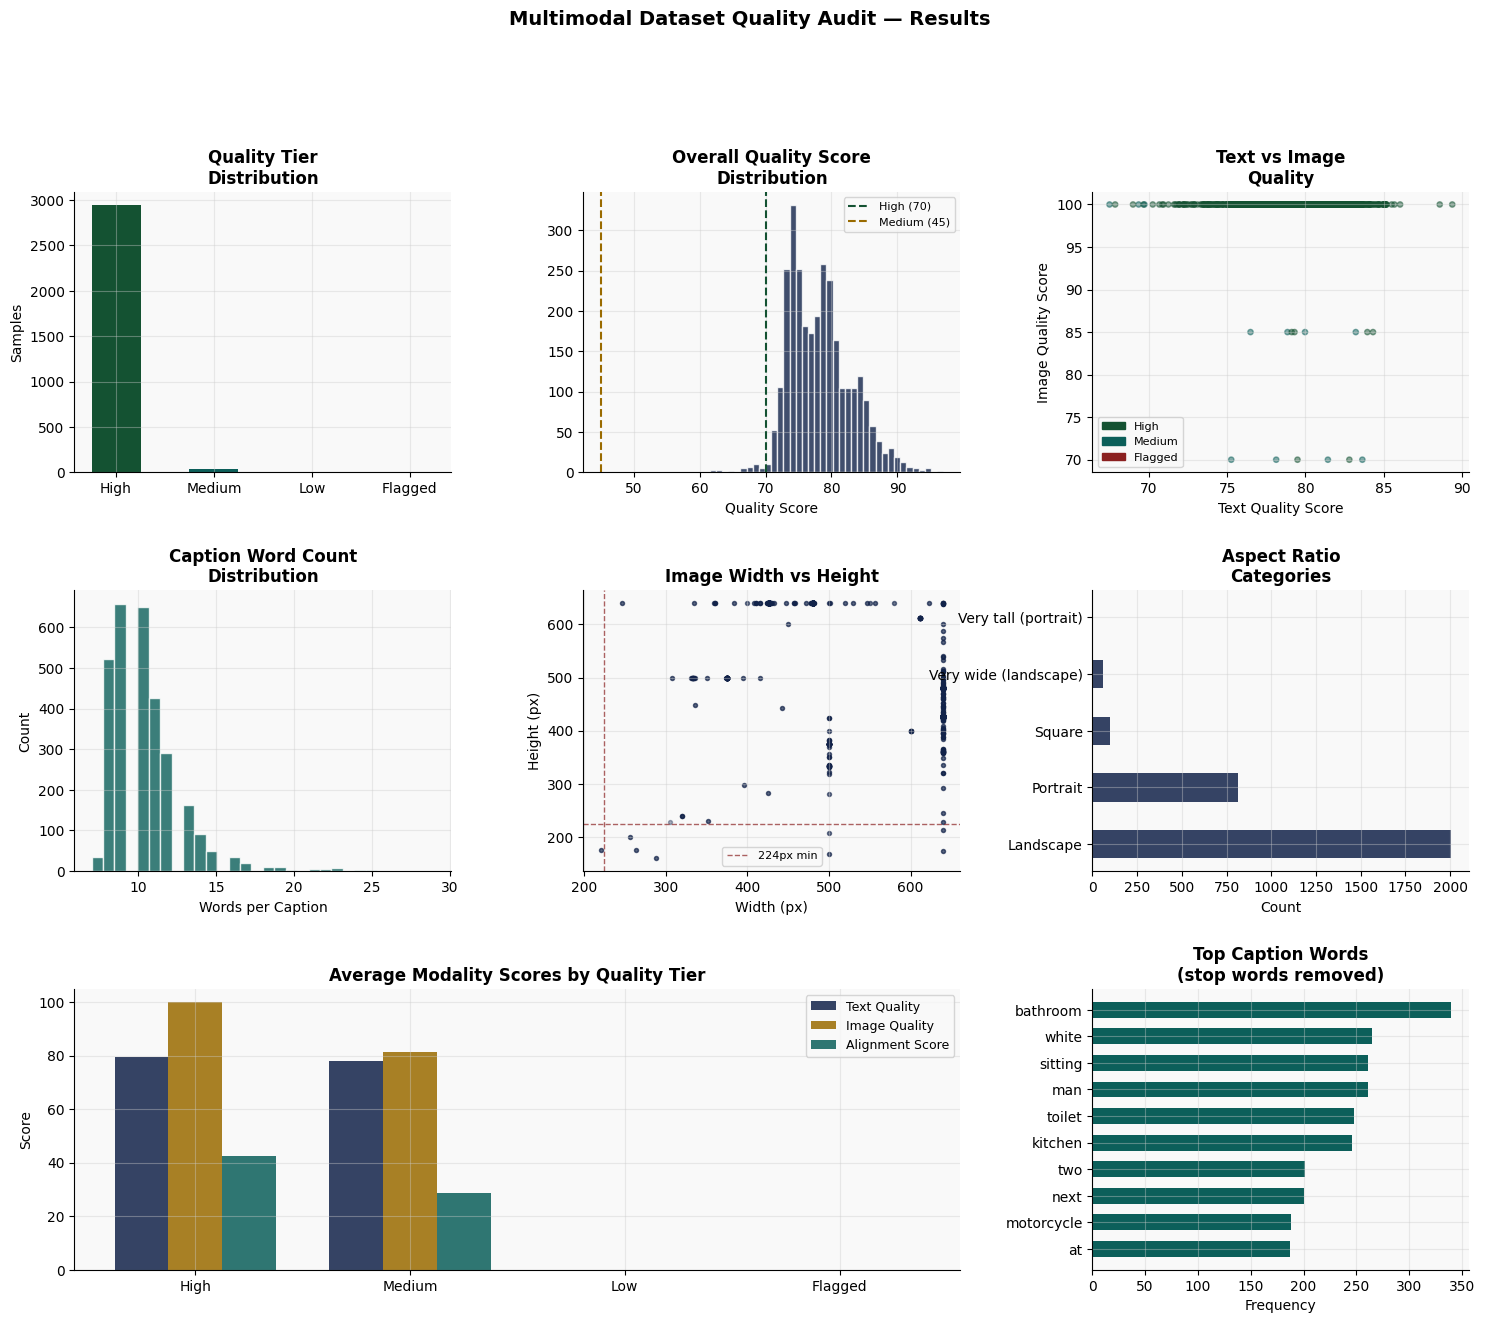

Saved: multimodal_audit.png


In [16]:
# Step 7 — Visualisations
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# Setup figure and colors
fig = plt.figure(figsize=(18,14))
gs  = gridspec.GridSpec(3,3,figure=fig, hspace=0.42, wspace=0.35)
NAVY='#12234A'; GOLD='#9A6B00'; TEAL='#0C5F5A'; GREEN='#145232'; RED='#8B2020'

# 1. Quality tier distribution
ax1 = fig.add_subplot(gs[0,0])
tiers = ['High','Medium','Low','Flagged']
# Ensure columns exist before plotting
if 'quality_tier' in df.columns:
    tc = [df['quality_tier'].value_counts().get(t,0) for t in tiers]
    ax1.bar(tiers, tc, color=[GREEN,TEAL,GOLD,RED], width=0.5)
ax1.set_title('Quality Tier\nDistribution', fontweight='bold')
ax1.set_ylabel('Samples')

# 2. Overall quality score histogram
ax2 = fig.add_subplot(gs[0,1])
if 'overall_quality' in df.columns:
    ax2.hist(df['overall_quality'], bins=40, color=NAVY, alpha=0.8, edgecolor='white')
    ax2.axvline(70, color=GREEN, ls='--', lw=1.5, label='High (70)')
    ax2.axvline(45, color=GOLD,  ls='--', lw=1.5, label='Medium (45)')
ax2.set_title('Overall Quality Score\nDistribution', fontweight='bold')
ax2.set_xlabel('Quality Score')
ax2.legend(fontsize=8)

# 3. Text vs image quality scatter
ax3 = fig.add_subplot(gs[0,2])
if 'quality_tier' in df.columns:
    sample_size = min(800, len(df))
    sample = df.sample(sample_size, random_state=42)
    sc_colors = [GREEN if t=='High' else TEAL if t=='Medium' else GOLD if t=='Low' else RED
                 for t in sample['quality_tier']]
    ax3.scatter(sample['text_quality'], sample['img_quality'], c=sc_colors, alpha=0.5, s=15)
ax3.set_xlabel('Text Quality Score')
ax3.set_ylabel('Image Quality Score')
ax3.set_title('Text vs Image\nQuality', fontweight='bold')
patches = [mpatches.Patch(color=GREEN,label='High'),
           mpatches.Patch(color=TEAL, label='Medium'),
           mpatches.Patch(color=RED,  label='Flagged')]
ax3.legend(handles=patches, fontsize=8)

# 4. Caption length distribution
ax4 = fig.add_subplot(gs[1,0])
ax4.hist(df['caption_words'].clip(upper=40), bins=30, color=TEAL, alpha=0.8, edgecolor='white')
ax4.set_title('Caption Word Count\nDistribution', fontweight='bold')
ax4.set_xlabel('Words per Caption')
ax4.set_ylabel('Count')

# 5. Image resolution distribution
ax5 = fig.add_subplot(gs[1,1])
ax5.scatter(df['img_width'].clip(upper=1000), df['img_height'].clip(upper=1000),
            alpha=0.2, s=8, color=NAVY)
ax5.axvline(224, color=RED, ls='--', lw=1, alpha=0.7, label='224px min')
ax5.axhline(224, color=RED, ls='--', lw=1, alpha=0.7)
ax5.set_title('Image Width vs Height', fontweight='bold')
ax5.set_xlabel('Width (px)')
ax5.set_ylabel('Height (px)')
ax5.legend(fontsize=8)

# 6. Aspect ratio distribution
ax6 = fig.add_subplot(gs[1,2])
if 'ar_category' in df.columns:
    ar_counts = df['ar_category'].value_counts()
    ax6.barh(ar_counts.index, ar_counts.values, color=NAVY, height=0.5, alpha=0.85)
ax6.set_title('Aspect Ratio\nCategories', fontweight='bold')
ax6.set_xlabel('Count')

# 7. Modality score comparison
ax7 = fig.add_subplot(gs[2,:2])
x = np.arange(4)
w = 0.25
if 'quality_tier' in df.columns:
    tier_text = [df[df['quality_tier']==t]['text_quality'].mean() if (df['quality_tier']==t).any() else 0 for t in tiers]
    tier_img  = [df[df['quality_tier']==t]['img_quality'].mean() if (df['quality_tier']==t).any() else 0 for t in tiers]
    tier_aln  = [df[df['quality_tier']==t]['alignment_score'].mean() if (df['quality_tier']==t).any() else 0 for t in tiers]
    ax7.bar(x-w, tier_text, w, label='Text Quality', color=NAVY, alpha=0.85)
    ax7.bar(x,   tier_img,  w, label='Image Quality', color=GOLD, alpha=0.85)
    ax7.bar(x+w, tier_aln,  w, label='Alignment Score', color=TEAL, alpha=0.85)
    ax7.set_xticks(x); ax7.set_xticklabels(tiers)
ax7.set_title('Average Modality Scores by Quality Tier', fontweight='bold')
ax7.set_ylabel('Score')
ax7.legend(fontsize=9)

# 8. Top caption words
ax8 = fig.add_subplot(gs[2,2])
all_words = ' '.join(df['caption'].astype(str).tolist()).lower().split()
stop = {'a','an','the','is','are','in','on','of','with','and','to','it'}
clean_words_counts = Counter([w for w in all_words if w not in stop]).most_common(10)
if clean_words_counts:
    words, counts = zip(*clean_words_counts)
    ax8.barh(words[::-1], counts[::-1], color=TEAL, height=0.6)
ax8.set_title('Top Caption Words\n(stop words removed)', fontweight='bold')
ax8.set_xlabel('Frequency')

fig.suptitle('Multimodal Dataset Quality Audit — Results', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('multimodal_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: multimodal_audit.png")

In [17]:
# Step 8 — Audit Report & Dataset Card Export

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj,(np.integer,)): return int(obj)
        if isinstance(obj,(np.floating,)): return float(obj)
        if isinstance(obj,(np.ndarray,)): return obj.tolist()
        return super().default(obj)

tier_counts_dict = df['quality_tier'].value_counts().to_dict()

dashboard = {
    'summary': {
        'total_pairs':       N,
        'after_dedup':       int(len(df)),
        'high_quality':      int(tier_counts_dict.get('High',0)),
        'medium_quality':    int(tier_counts_dict.get('Medium',0)),
        'low_quality':       int(tier_counts_dict.get('Low',0)),
        'flagged':           int(tier_counts_dict.get('Flagged',0)),
        'retention_rate':    round(len(df)/N*100, 2),
    },
    'text_audit': {
        'avg_quality_score': round(float(df['text_quality'].mean()),2),
        'avg_caption_words': round(float(df['caption_words'].mean()),2),
        'vocab_size':        int(vocab_size),
        'type_token_ratio':  round(type_token_ratio, 4),
        'flagged_count':     int((df['n_text_flags']>0).sum()),
    },
    'image_audit': {
        'avg_quality_score': round(float(df['img_quality'].mean()),2),
        'avg_width':         round(float(df['img_width'].mean()),1),
        'avg_height':        round(float(df['img_height'].mean()),1),
        'low_res_count':     int(df['img_flags'].apply(lambda x: 'low_res' in x).sum()),
        'non_rgb_count':     int((df['img_mode']!='RGB').sum()),
    },
    'alignment': {
        'avg_alignment_score': round(float(df['alignment_score'].mean()),2),
    },
    'deduplication': {
        'exact_removed': int(exact_removed),
        'near_removed':  int(near_removed),
    },
    'quality_tiers': tier_counts_dict,
    'tier_scores': {
        t: {
            'text': round(float(df[df['quality_tier']==t]['text_quality'].mean()),2) if (df['quality_tier']==t).any() else 0,
            'image': round(float(df[df['quality_tier']==t]['img_quality'].mean()),2) if (df['quality_tier']==t).any() else 0,
            'alignment': round(float(df[df['quality_tier']==t]['alignment_score'].mean()),2) if (df['quality_tier']==t).any() else 0,
        } for t in ['High','Medium','Low','Flagged']
    },
    'aspect_ratios': df['ar_category'].value_counts().to_dict(),
    'dataset_card': {
        'name':     'MS-COCO Multimodal Quality Audit',
        'source':   'HuggingFaceM4/COCO (HuggingFace)',
        'modalities':['text_captions','images'],
        'filters':  ['deduplication','text_quality','image_quality','alignment_scoring','toxicity_flagging'],
        'run_date': datetime.now().strftime('%Y-%m-%d'),
    }
}

with open('multimodal_audit_data.json','w') as f:
    json.dump(dashboard, f, indent=2, cls=NpEncoder)

print("AUDIT REPORT")
print("="*55)
print(f"  Total pairs ingested:  {N:,}")
print(f"  After deduplication:   {len(df):,}")
print(f"  High quality:          {tier_counts_dict.get('High',0):,}")
print(f"  Medium quality:        {tier_counts_dict.get('Medium',0):,}")
print(f"  Low quality:           {tier_counts_dict.get('Low',0):,}")
print(f"  Flagged:               {tier_counts_dict.get('Flagged',0):,}")
print(f"  Retention rate:        {len(df)/N*100:.1f}%")
print(f"  Avg text quality:      {df['text_quality'].mean():.2f}")
print(f"  Avg image quality:     {df['img_quality'].mean():.2f}")
print(f"  Avg alignment score:   {df['alignment_score'].mean():.2f}")
print()
print("Exported: multimodal_audit_data.json")

AUDIT REPORT
  Total pairs ingested:  3,000
  After deduplication:   2,983
  High quality:          2,944
  Medium quality:        39
  Low quality:           0
  Flagged:               0
  Retention rate:        99.4%
  Avg text quality:      79.44
  Avg image quality:     99.61
  Avg alignment score:   42.39

Exported: multimodal_audit_data.json
